In [1]:
import cafe

cafe.logger.setLevel("DEBUG")

INFO                                                                                                                                                                                                    
             ██████╗ █████╗ ███████╗███████╗                                                                                                                                                            
           ██╔════╝██╔══██╗██╔════╝██╔════╝                                                                                                                                                             
           ██║     ███████║█████╗  █████╗                                                                                                                                                               
           ██║     ██╔══██║██╔══╝  ██╔══╝                                                                                                                                                           

In [2]:
sub_filename = ".cafe/gastrulation_blood/h5ad/gastrulation_blood.h5ad"
fadata = cafe.data.read_h5ad(sub_filename)
fadata.prior_information["basis"]="X_umap"
fadata

DEBUG    |- Create a FateAnnData object from an existing AnnData object.                                                                                                                                
DEBUG    |- recognizing prior information...                                                                                                                                                            
DEBUG    |--- recognize 'celltype' in '.obs' columns as 'cluster' key                                                                                                                                   
DEBUG    |--- recognize 'X_umap' in '.obsm' keys as 'basis' key                                                                                                                                         
DEBUG    |- unserialize trajectory dict: 'ref_coarse_cluster'                                                                                                                                       

AnnData object with n_obs × n_vars = 12332 × 53801
    obs: 'barcode', 'sample', 'stage', 'sequencing.batch', 'theiler', 'doub.density', 'doublet', 'cluster', 'cluster.sub', 'cluster.stage', 'cluster.theiler', 'stripped', 'celltype', 'colour', 'umapX', 'umapY', 'haem_gephiX', 'haem_gephiY', 'haem_subclust', 'endo_gephiX', 'endo_gephiY', 'endo_trajectoryName', 'endo_trajectoryDPT', 'endo_gutX', 'endo_gutY', 'endo_gutDPT', 'endo_gutCluster', 'cell_velocyto_loom', 'celltype_coarse', 'celltype_new', 'pseudotime'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand'
    uns: 'cafe', 'celltype_coarse_colors', 'celltype_colors', 'celltype_new_colors', 'id'
    obsm: 'X_pca', 'X_stavia', 'X_umap'
    layers: 'spliced', 'unspliced'

In [3]:
import scvelo as scv

scv.pp.filter_and_normalize(fadata, min_counts=3, min_counts_u=3, n_top_genes=2000)
scv.pp.moments(fadata)

WARNING  |- Both milestone_percentages and progressions are given, will only use progressions                                                                                                           
WARNING  |- Both milestone_percentages and progressions are given, will only use progressions                                                                                                           
WARNING  |- Both milestone_percentages and progressions are given, will only use progressions                                                                                                           
WARNING  |- Both milestone_percentages and progressions are given, will only use progressions                                                                                                           
Filtered out 35109 genes that are detected 3 counts (spliced).
WARNING  |- Both milestone_percentages and progressions are given, will only use progressions                                        

In [4]:
method_name = "veloae"
method = cafe.method.FateMethod(method_name)
method.infer_trajectory(fadata, parameters={"repreprocess": False}, id=method_name)

DEBUG    |- load conda backend                                                                                                                                                                          
DEBUG    |--- Conda environment 'veloae' is available: Python 3.10.18                                                                                                                                   
DEBUG    |- Loaded function 'veloae': <function veloae at 0x732c66041fc0>                                                                                                                               
INFO     |- method backend loaded: CondaBackend: veloae in conda env 'veloae'                                                                                                                           
DEBUG    |- set new log file: ./.cafe/gastrulation_blood/log/veloae.log                                                                                                                             

DEBUG    |- extract 'celltype' from prior infomation as parameter 'color'                                                                                                                               
DEBUG    |- extract 'X_umap' from prior infomation as parameter 'basis'                                                                                                                                 
DEBUG    |- calculate new trajectory embedding for model_name:veloae, basis:X_umap.                                                                                                                     
DEBUG    |- add waypoints                                                                                                                                                                               
DEBUG    |- FateAnnData add_waypoints                                                                                                                                                               

array([[<Axes: title={'center': 'veloae(celltype)'}, xlabel='_milestone_network_emb1', ylabel='_milestone_network_emb2'>]],
      dtype=object)

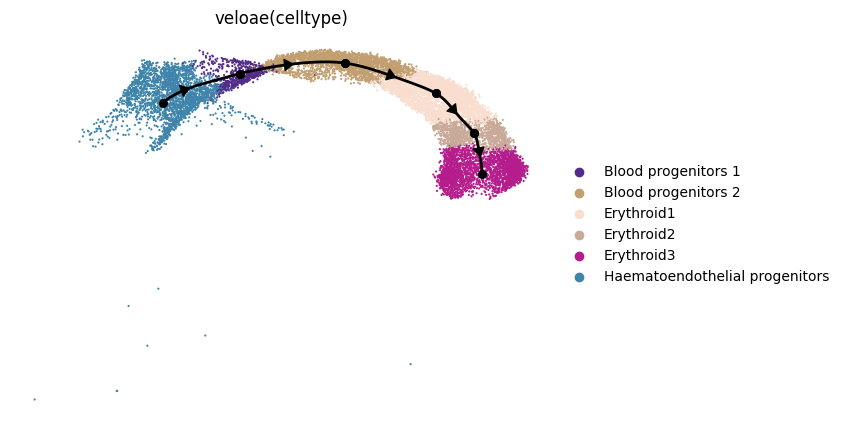

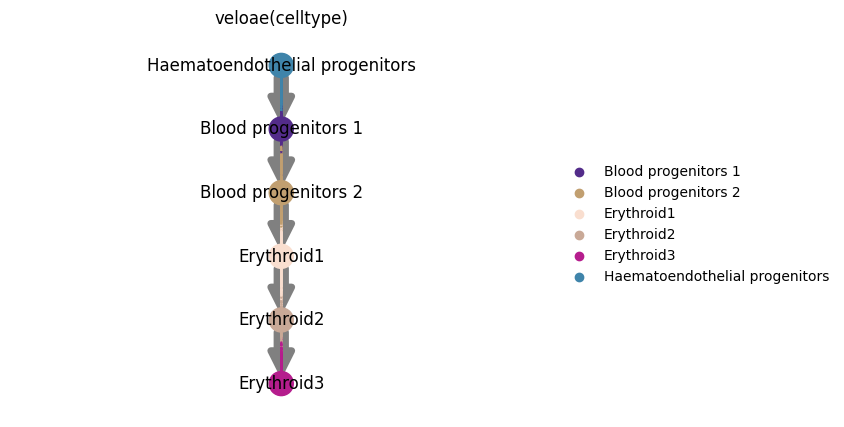

In [5]:
cafe.plot.plot_trajectory(fadata)
cafe.plot.plot_graph(fadata)

符合理想情况：Haematoendothelial progenitors-> Blood progenitors 1 -> Blood progenitors 2 -> Erythroid1 -> Erythroid2 -> Erythroid3

In [6]:
fadata.id = "gastrulation_blood"
fadata.check_result_dir()
fadata.write_trajectory_dict(model_name_list=["veloae"])

DEBUG    |- write trajectory 'veloae' to './.cafe/gastrulation_blood/trajectory_history/veloae.pkl'                                                                                                     
